## Librerías y Carga de Datos.

In [36]:
USE_PLOTLY = False

In [ ]:
# Los parámetros comunes del gráfico
common_cv_args = {
    'initial_weeks': 52 * 3,  # 3 años de entrenamiento inicial
    'period_weeks': 52 * 1,   # Re-entrenar cada 1 años
    'horizon_weeks': 52,      # Predecir a 1 año
    'plot_cv_metric':True,
    'metric':'mape', 
    'show_performance_metrics':True
}

In [38]:
# !pip install prophet
import sys
sys.path.append('../../')
import src.utils.helpers as func
from src.utils.helpers import setup_logging
import src.evaluation.metrics as meval
from src.utils.ts_diagnostics import StationarityAnalyzer, analyze_decomposition
from src.visualization import tsa_plots as tsp
from src.evaluation.interpretability import get_xbg_feature_importance
from src.evaluation.plots import plot_last_year, plot_residuals_distribution, plot_forecast, plot_prophet_forecast, plot_prophet_components
from src.features.build_features import create_basic_time_features, prepare_data
from src.features.prophet_preprocessing import prophet_df, get_weekly_holidays_df
from src.evaluation.validation import cross_validation_prophet

In [39]:
setup_logging(root_level="WARNING", prophet_level="INFO", cmdstanpy_level="WARNING", silence_cmdstanpy=True)

from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf as sm_plot_acf
import numpy as np
import plotly.graph_objects as go
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
from tabulate import tabulate
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, f_classif
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import prince as pr
import plotly.express as px
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.make_holidays import make_holidays_df

# import warnings
import plotly.offline as py
py.init_notebook_mode()
# warnings.filterwarnings("ignore")

In [40]:
path = '../../data/processed/df_acumulado.parquet'
data = func.load_data(path, show_info=False)

Cargando datos desde: ../../data/processed/df_acumulado.parquet
Datos cargados exitosamente.


In [41]:
df = prepare_data(data,'fecha', 'valor_acumulado_corregido','valor')
data_prophet = prophet_df(df, 'fecha', 'valor')
data_prophet.head()

,ds,y
0,2014-01-06,131.0
1,2014-01-13,658.0
2,2014-01-20,933.0
3,2014-01-27,1023.0
4,2014-02-03,1151.0


## Modelo Prophet Simple

In [42]:
m = Prophet(weekly_seasonality=False)
m.add_seasonality(name='anual', period=365.25 / 7, fourier_order=10)


prophet: INFO - Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


### Backtesting

##### Walk-Fordward

##### Cross Validation

prophet: INFO - Making 8 forecasts with cutoffs between 2017-01-02 00:00:00 and 2023-12-25 00:00:00


  0%|          | 0/8 [00:00<?, ?it/s]


--- Métricas de Rendimiento Promedio (Horizonte = 1 año) ---


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
42,336 days,495318.139885,703.788420,562.976570,0.250152,0.201217,0.269204,0.378049
43,343 days,490802.991328,700.573330,560.583010,0.253330,0.201698,0.273654,0.375000
44,350 days,511805.440995,715.405788,558.731612,0.251881,0.201894,0.279065,0.420732
45,357 days,517378.116978,719.290009,575.571591,0.269571,0.226689,0.301161,0.353659
46,364 days,528655.096041,727.086718,594.123426,0.308736,0.291454,0.347952,0.301829


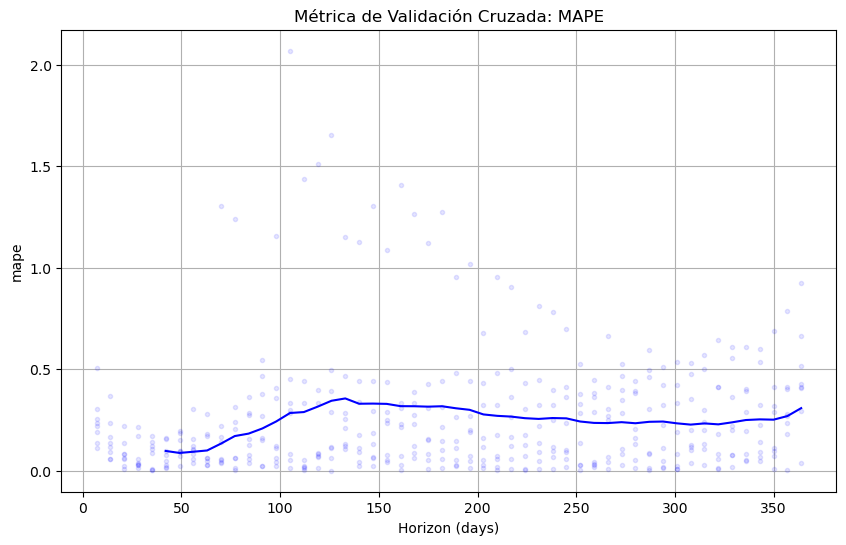

In [ ]:
m.fit(data_prophet)
df_cv = cross_validation_prophet(m, **common_cv_args)

### Predictions

In [44]:
future = m.make_future_dataframe(periods=52, freq = 'W')
forecast = m.predict(future)

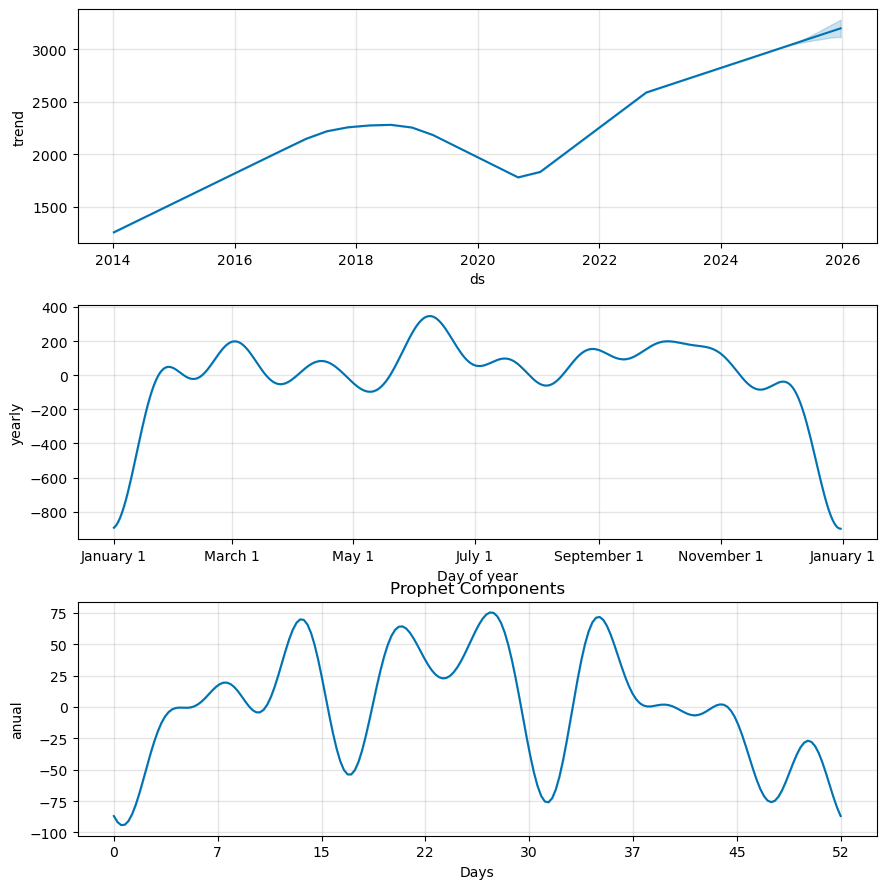

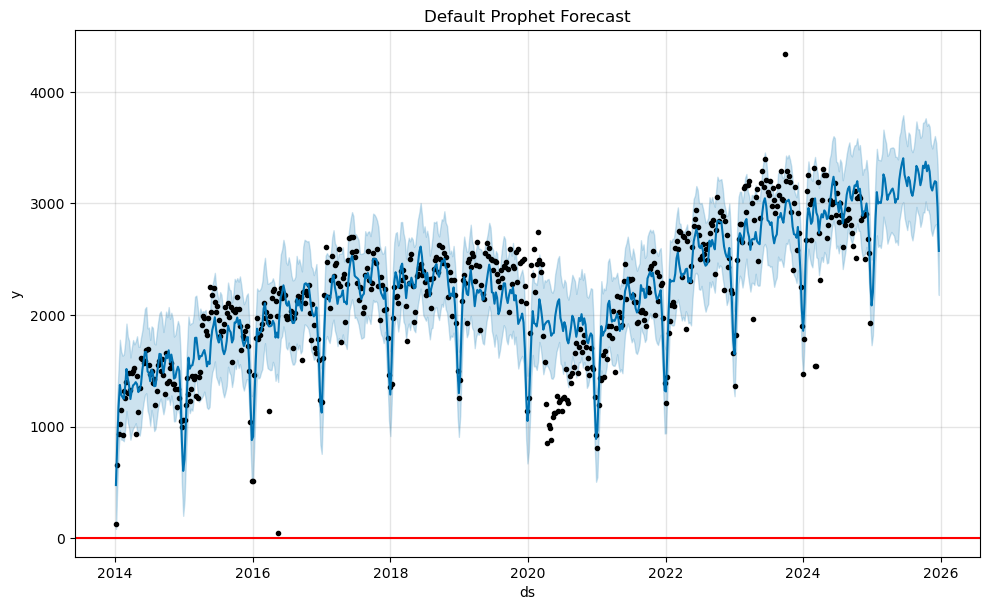

In [45]:
plot_prophet_components(m, forecast, plotly_engine=USE_PLOTLY)
plot_prophet_forecast(m, forecast, plotly_engine=USE_PLOTLY)


## Modelo Prophet holidays

In [46]:
adapted_mx_holidays = get_weekly_holidays_df(data=data_prophet, date_col='ds', country='MX', forecast_horizon=1)
adapted_mx_holidays.head()

,ds,holiday,lower_window,upper_window
0,2014-01-01,New Year's Day,-6,0
1,2014-02-03,Constitution Day,-6,0
2,2014-03-17,Benito Juárez's birthday,-6,0
3,2014-05-01,Labor Day,-6,0
4,2014-09-16,Independence Day,-6,0


In [47]:
m2 = Prophet(weekly_seasonality=False, holidays=adapted_mx_holidays)
m2.fit(data_prophet)

prophet: INFO - Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


### Backtesting

prophet: INFO - Making 8 forecasts with cutoffs between 2017-01-02 00:00:00 and 2023-12-25 00:00:00


  0%|          | 0/8 [00:00<?, ?it/s]


--- Métricas de Rendimiento Promedio (Horizonte = 1 año) ---


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
42,336 days,491510.073087,701.077794,563.797219,0.251604,0.201553,0.268206,0.402439
43,343 days,477045.061645,690.684488,552.801207,0.250991,0.202636,0.267413,0.423780
44,350 days,493621.711086,702.582174,552.339521,0.250163,0.225672,0.272484,0.448171
45,357 days,500271.249031,707.298557,561.933479,0.262610,0.225672,0.294902,0.378049
46,364 days,555785.046627,745.509924,584.739196,0.297629,0.231452,0.341354,0.350610


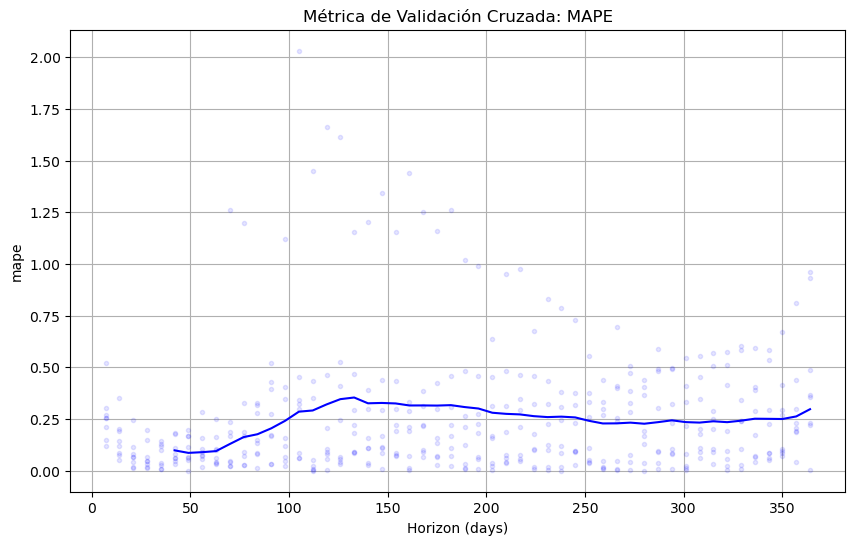

In [48]:
df_cv2 = cross_validation_prophet(m2, **common_cv_args)

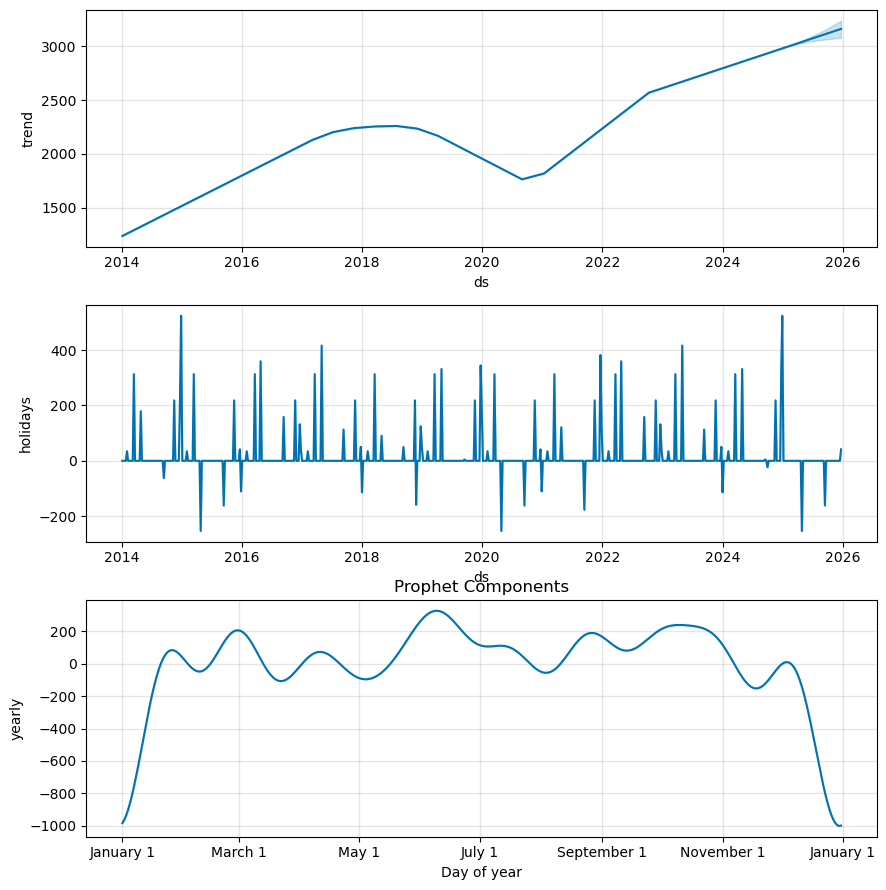

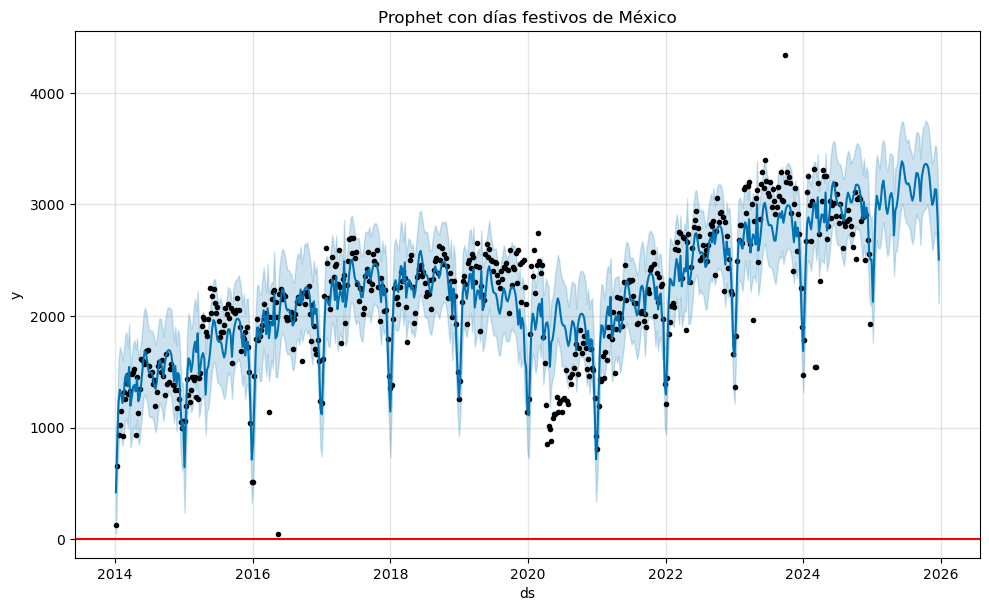

In [59]:
future2 = m2.make_future_dataframe(periods=52, freq = 'W')
forecast2 = m2.predict(future2)
plot_prophet_components(m2, forecast2, plotly_engine=USE_PLOTLY)
plot_prophet_forecast(m2, forecast2, plotly_engine=USE_PLOTLY, title="Prophet con días festivos de México")

In [50]:
def get_upper_window_date(data, date_col='ds', upper_col='ds_upper'):
    df = data.copy()
    for ts_col in [date_col, upper_col]:
        df[ts_col] = pd.to_datetime(df[ts_col])
    df['upper_window'] = (df[upper_col] - df[date_col]).dt.days
    return df

## Modelo Prophet Covid

### Fases Epidemiologicas

In [51]:
fases_epidemiologicas = pd.DataFrame([
    {'holiday': 'importación_de_casos', 'ds': '2020-02-28', 'lower_window': 0, 'ds_upper': '2020-03-23'},
    {'holiday': 'transmisión_comunitaria', 'ds': '2020-03-24', 'lower_window': 0, 'ds_upper': '2020-04-20'},
    {'holiday': 'etapa_epidemiológica', 'ds': '2020-04-21', 'lower_window': 0, 'ds_upper': '2020-05-01'}])
fases_epidemiologicas = get_upper_window_date(fases_epidemiologicas, date_col='ds', upper_col='ds_upper')
display(fases_epidemiologicas.head())

,holiday,ds,lower_window,ds_upper,upper_window
0,importación_de_casos,2020-02-28,0,2020-03-23,24
1,transmisión_comunitaria,2020-03-24,0,2020-04-20,27
2,etapa_epidemiológica,2020-04-21,0,2020-05-01,10


In [52]:
m3 = Prophet(holidays=fases_epidemiologicas, weekly_seasonality=False)
# m3.add_regressor()
m3.fit(data_prophet)

prophet: INFO - Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


#### Backtesting

prophet: INFO - Making 8 forecasts with cutoffs between 2017-01-02 00:00:00 and 2023-12-25 00:00:00


  0%|          | 0/8 [00:00<?, ?it/s]


--- Métricas de Rendimiento Promedio (Horizonte = 1 año) ---


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
42,336 days,471937.039972,686.976739,559.400701,0.248830,0.195480,0.263214,0.426829
43,343 days,459163.509755,677.616049,549.850973,0.248583,0.195827,0.262896,0.448171
44,350 days,472510.520665,687.394007,548.853971,0.247489,0.209260,0.267644,0.426829
45,357 days,475768.050974,689.759415,558.749721,0.261532,0.215886,0.287205,0.353659
46,364 days,475377.547295,689.476285,567.189119,0.294212,0.266775,0.325593,0.301829


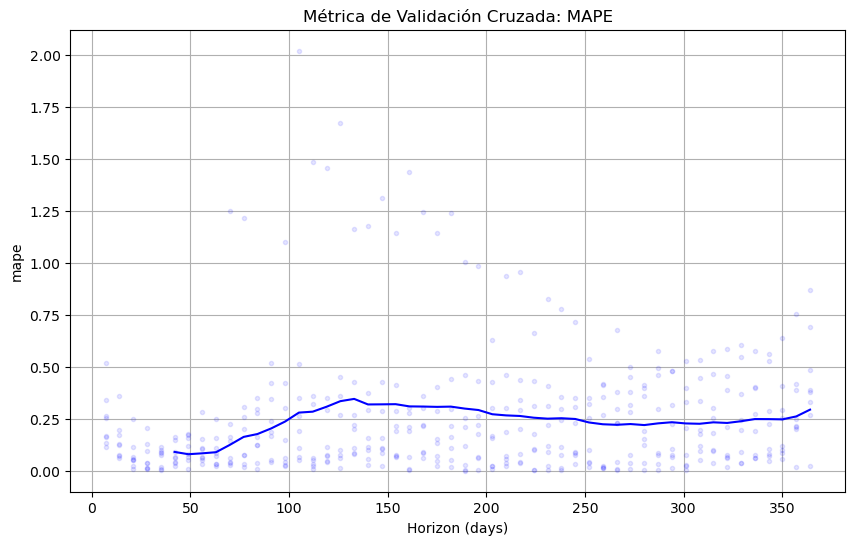

In [53]:
df_cv3 = cross_validation_prophet(m3, **common_cv_args)

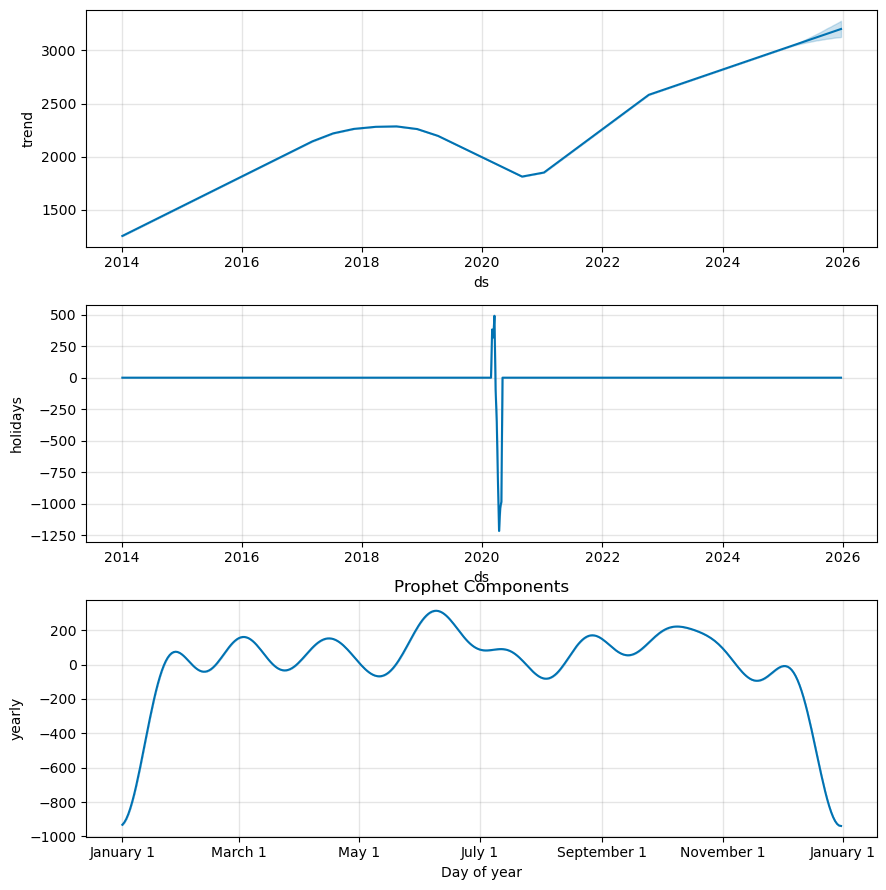

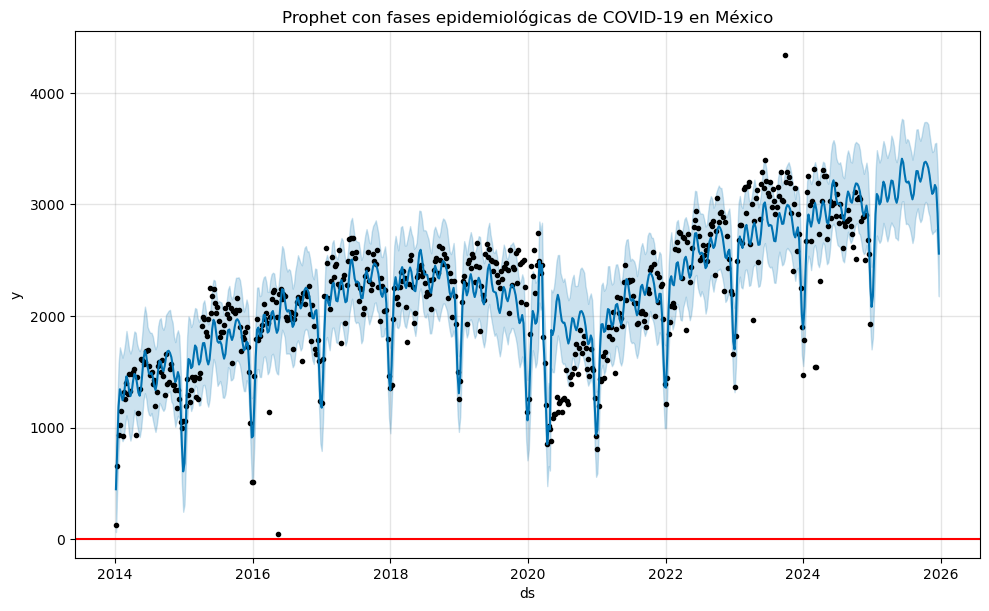

In [60]:
future3 = m3.make_future_dataframe(periods=52, freq = 'W')
forecast3 = m3.predict(future3)
plot_prophet_components(m3, forecast3, plotly_engine=USE_PLOTLY)
plot_prophet_forecast(m3, forecast3, plotly_engine=USE_PLOTLY, title="Prophet con fases epidemiológicas de COVID-19 en México")

### Fases de Recuperacion

In [55]:
fases_recuperacion = pd.DataFrame([
    {'holiday': 'etapa1', 'ds': '2020-05-14', 'lower_window': 0, 'ds_upper': '2020-05-17'},
    {'holiday': 'etapa2', 'ds': '2020-05-18', 'lower_window': 0, 'ds_upper': '2020-05-31'},
    {'holiday': 'etapa3', 'ds': '2020-06-01', 'lower_window': 0, 'ds_upper': '2022-05-01'}])
fases_recuperacion = get_upper_window_date(fases_recuperacion, date_col='ds', upper_col='ds_upper')
display(fases_recuperacion.head())

,holiday,ds,lower_window,ds_upper,upper_window
0,etapa1,2020-05-14,0,2020-05-17,3
1,etapa2,2020-05-18,0,2020-05-31,13
2,etapa3,2020-06-01,0,2022-05-01,699


In [ ]:
m4 = Prophet(holidays=fases_recuperacion, weekly_seasonality=False)
# m4.add_regressor()

prophet: INFO - Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


#### Backtesting

##### Walk-Fordward

##### Cross Validation

prophet: INFO - Making 8 forecasts with cutoffs between 2017-01-02 00:00:00 and 2023-12-25 00:00:00


  0%|          | 0/8 [00:00<?, ?it/s]


--- Métricas de Rendimiento Promedio (Horizonte = 1 año) ---


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
42,336 days,290845.462056,539.300901,437.659912,0.196995,0.121109,0.197181,0.472561
43,343 days,279446.698758,528.627183,431.808699,0.197433,0.119436,0.197124,0.500000
44,350 days,285563.480962,534.381400,438.921995,0.200532,0.119436,0.203792,0.500000
45,357 days,278194.167538,527.441151,432.352518,0.206626,0.145363,0.212467,0.475610
46,364 days,256346.004218,506.306236,418.391987,0.224556,0.210707,0.228747,0.448171


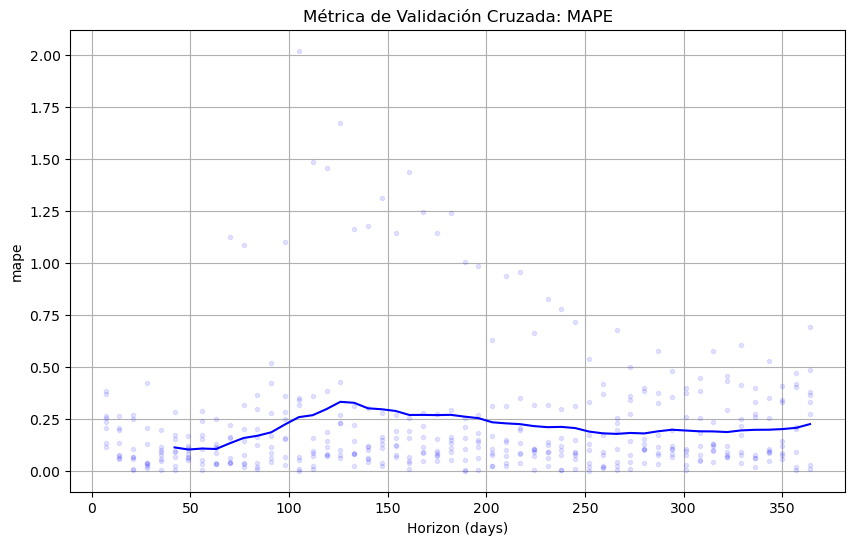

In [ ]:
m4.fit(data_prophet)
df_cv4 = cross_validation_prophet(m4, **common_cv_args)

#### Predicciones

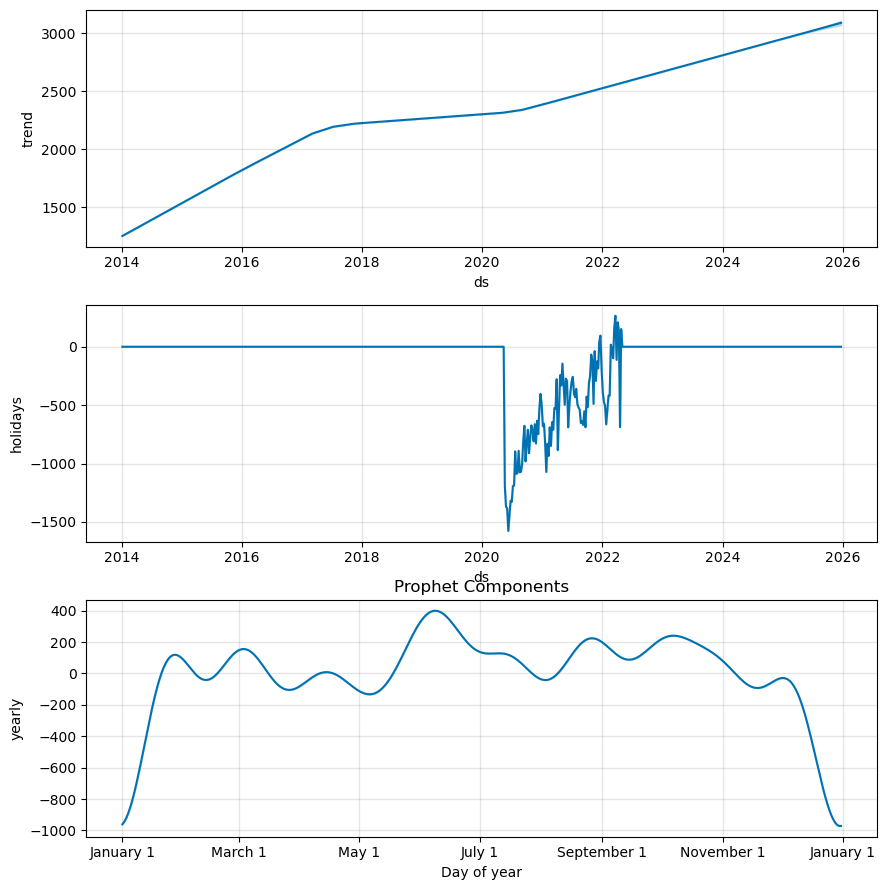

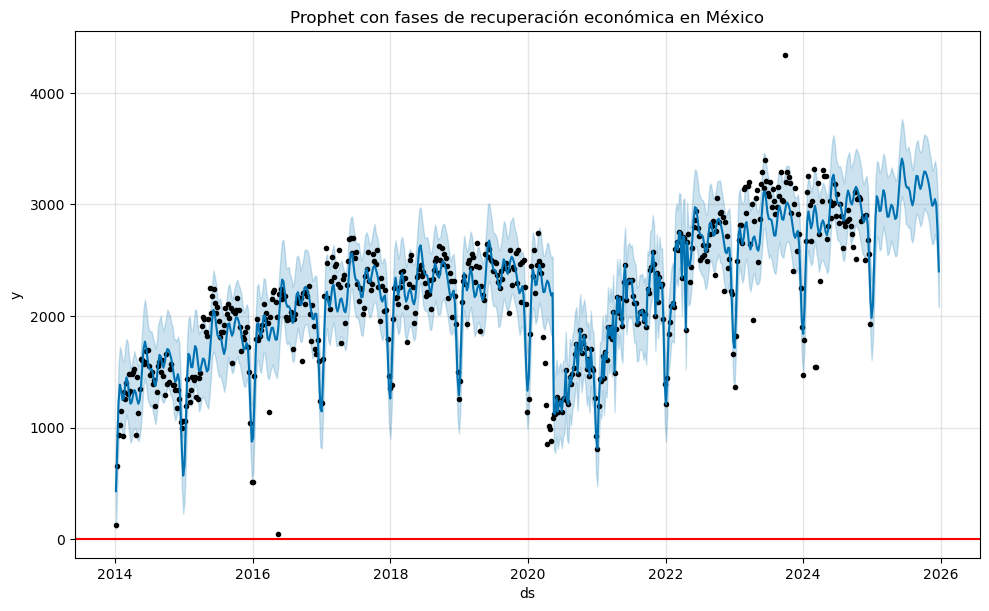

In [61]:
future4 = m4.make_future_dataframe(periods=52, freq = 'W')
forecast4 = m4.predict(future4)
plot_prophet_components(m4, forecast4, plotly_engine=USE_PLOTLY)
plot_prophet_forecast(m4, forecast4, plotly_engine=USE_PLOTLY, title="Prophet con fases de recuperación económica en México")